# TODOS
- Change the addition functions to be able to handle arbitrary size registers (a and b are different sizes)
- Use the new addition function to perform the +1 step in the 2s complement function without having to create a massive register just to hold the number "1"

# I will now be building the basic arithmetic operations from the Clifford + T gate set

Allowed gates are Clifford gates: H, S, X, Y, Z, I, CNOT and all of their inverses  (add to this list any other Clifford gate I need, this isn't meant to be exhaustive)

and the only non-Clifford gate allowed is T

In [64]:
from math import pi, acos, sqrt
from qiskit import QuantumCircuit, QuantumRegister, Aer, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.circuit.library import StatePreparation, CXGate, XGate, QFT, HGate, RYGate, U1Gate, IntegerComparator, DraperQFTAdder, UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Operator
import numpy as np

# From Subarithmetic-circuit.ipynb, these are the subarithmetic circuits:

In [76]:
def T_dagger_gate(qc,x):
    qc.sdg(x[0])
    qc.t(x[0])

# applies a 1 qubit V gate to the x register
def V_gate(qc, x, dagger=False):
    qc.h(x[0])

    if dagger:
        qc.sdg(x[0])
    else:
        qc.s(x[0])

    qc.h(x[0])

# applies the 2 qubit controlled S gate
def CS_gate(qc, x, dagger=False):
    if dagger:
        T_dagger_gate(qc, [x[1]]) # inverse of the T gate
        T_dagger_gate(qc, [x[0]]) # inverse of the T gate
    else:
        qc.t(x[1])
        qc.t(x[0])

    qc.cx(x[1],x[0]) # controlled not gate

    if dagger:
        qc.t(x[0])
    else:
        T_dagger_gate(qc, [x[0]]) # inverse of the T gate

    qc.cx(x[1],x[0]) # controlled not gate

# applies a controlled V gate to the 2 qubit x register, with the control being on the 2nd qubit (more significant)
def CV_gate(qc, x, dagger=False):
    qc.h(x[0])

    CS_gate(qc, x, dagger=dagger)

    qc.h(x[0])

# applies a Toffoli gate on the 3 qubit x register, with the control being on the 2nd and 3rd (more significant) qubits 
def Toffoli_gate(qc, x, useElementaryGates=True):
    if useElementaryGates:
        CV_gate(qc, [x[0], x[2]])
        qc.cx(x[1], x[2])
        CV_gate(qc, [x[0], x[1]])
        CV_gate(qc, [x[0], x[2]], dagger=True)
        qc.cx(x[1], x[2])
    else:
        qc.ccx(x[1], x[2], x[0]) # using the built-in Toffoli gate

# applies a Peres gate on the 3 qubit x register, with the 3rd qubit being the "A" input, the 2nd qubit being the "B" input, and the 1st qubit being the "C" input 
def Peres_gate(qc, x, useElementaryGates=True):
    if useElementaryGates:
        CV_gate(qc, [x[0], x[2]], dagger=True)
        CV_gate(qc, [x[0], x[1]], dagger=True)
        qc.cx(x[2], x[1])
        CV_gate(qc, [x[0], x[1]])
    else:
        P = np.array([
            [1,0,0,0,0,0,0,0],
            [0,1,0,0,0,0,0,0],
            [0,0,1,0,0,0,0,0],
            [0,0,0,1,0,0,0,0],
            [0,0,0,0,0,0,0,1],
            [0,0,0,0,0,0,1,0],
            [0,0,0,0,1,0,0,0],
            [0,0,0,0,0,1,0,0]
        ], dtype=complex)

        peres_gate = UnitaryGate(P, label='Peres')

        qc.append(peres_gate, [x[0],x[1],x[2]])


# Now for the new Arithmetic Functions

In [ ]:
# From section 4 of https://arxiv.org/pdf/1712.02630
def Addition_gate(qc, a, b, modular=False, useElementaryGates=True):
    n = len(a)
    if n + int(not modular) != len(b):
        raise Exception("a and b registers are not the same length for modular addition")
    
    # Step 1
    for i in range(1, n):
        qc.cx(a[i], b[i])

    qc.barrier(label="Step 2")

    # Step 2
    if not modular:
        qc.cx(a[n-1], b[n])
    for i in range(n-2,0,-1):
        qc.cx(a[i], a[i+1])

    qc.barrier(label="Step 3")

    # Step 3
    for i in range(n-1):
        qc.barrier(label="Toffoli Gate")
        Toffoli_gate(qc, [a[i+1], a[i], b[i]], useElementaryGates = useElementaryGates) # using Clifford + T gates

    qc.barrier(label="Step 4")

    # Step 4
    if not modular:
        Peres_gate(qc, [b[n], b[n-1], a[n-1]], useElementaryGates = useElementaryGates)
    else:
        qc.cx(a[n-1], b[n-1])
    for i in range(n-2, -1,-1):
        qc.barrier(label="Peres Gate")
        Peres_gate(qc, [a[i+1], b[i], a[i]], useElementaryGates = useElementaryGates)

    qc.barrier(label="Step 5")

    # Step 5
    for i in range(1, n-1):
        qc.cx(a[i], a[i+1])

    qc.barrier(label="Step 6")  
    
    # Step 6
    for i in range(1, n):
        qc.cx(a[i], b[i])

def Ones_complement(qc, a):
    for i in range(len(a)):
        qc.x(a[i])

def Twos_complement(qc, a):
    Ones_complement(qc, a)




# Modular Addition
$\ket{b}^{n} \ket{a}^n \rightarrow \ket{(a+b) \% 2^{n}}^{n} \ket{a}^n$

{'cx': 11, 'barrier': 11, 'ccx': 3, 'unitary': 3}


C:\Users\linco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


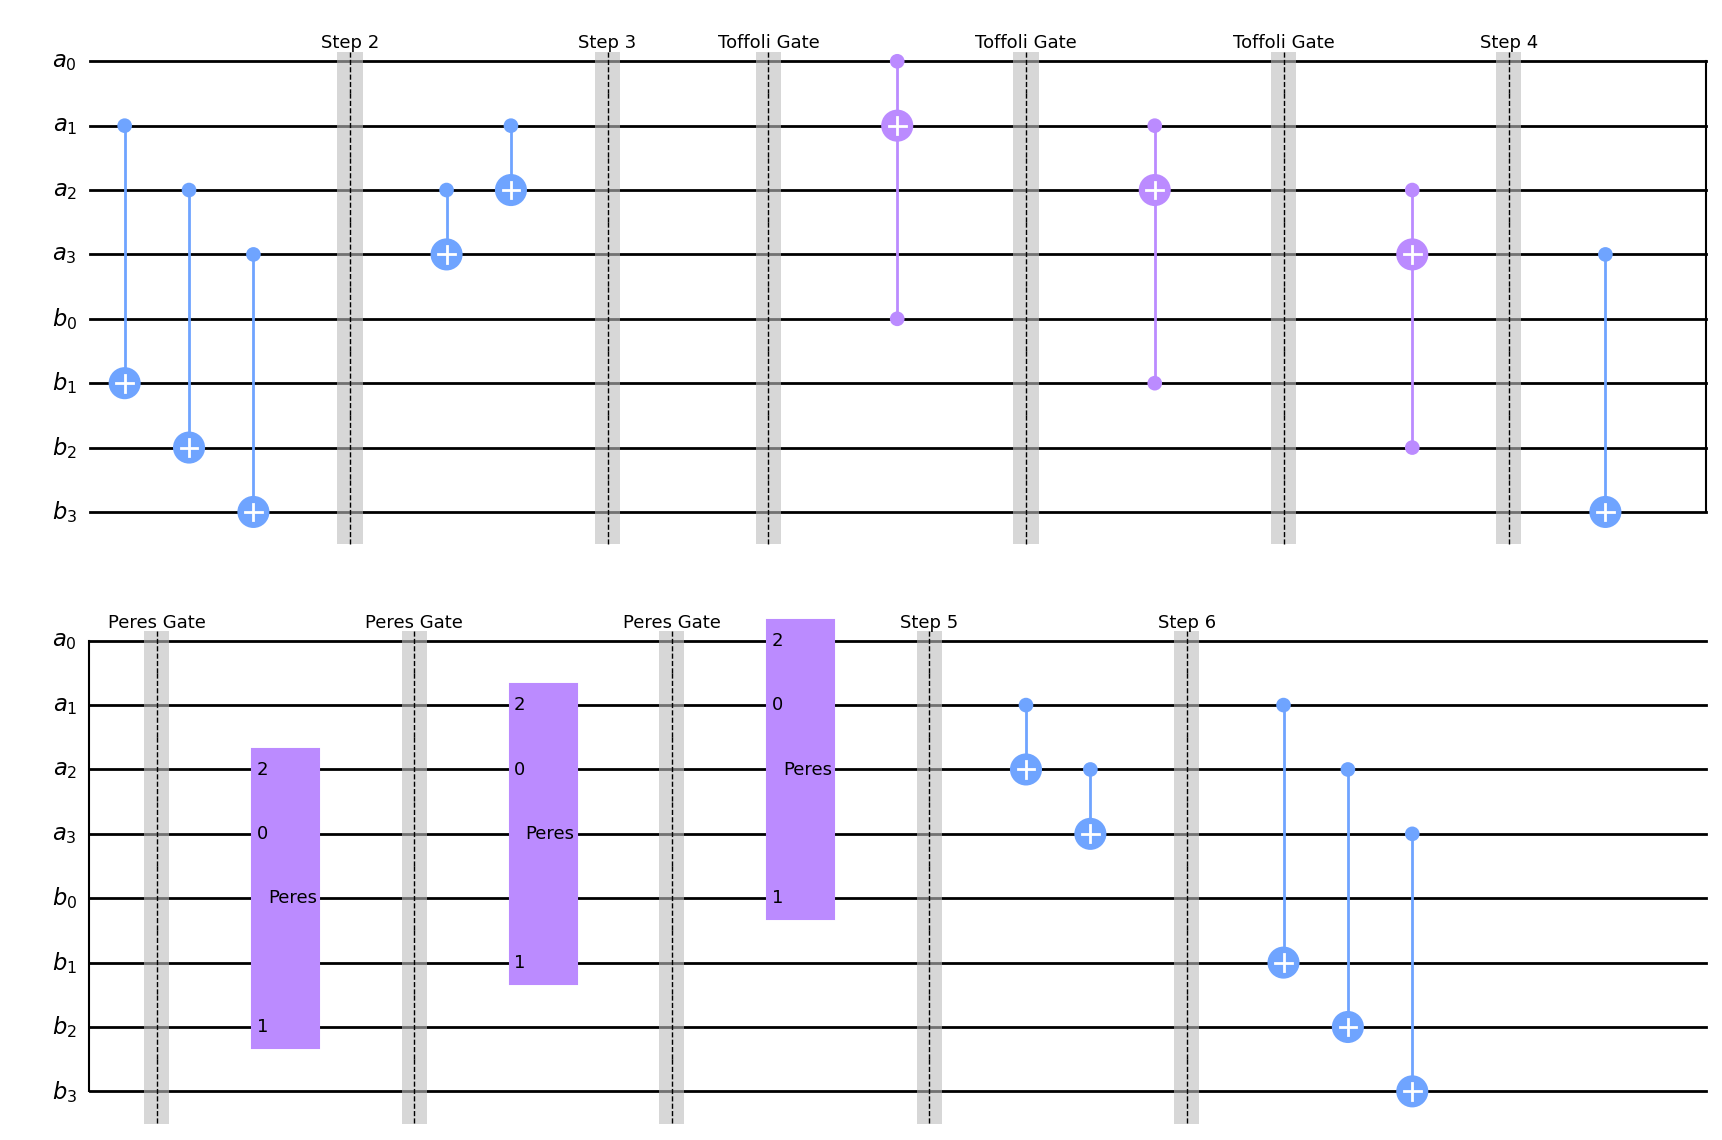

In [123]:
n = 4 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register
b = QuantumRegister(n, 'b') # "B" register

qc = QuantumCircuit(a, b)

Addition_gate(qc, a, b, modular=True, useElementaryGates=False)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
for b_val in range(int(2**n)):
    for a_val in range(int(2**n)):
        integer_input = b_val * int(2**n) + a_val
        state_vec = np.zeros(int(2**(2*n)))
        state_vec[integer_input] = 1
        input_state = Statevector(state_vec)

        # Apply the circuit to the state
        output_state = input_state.evolve(qc)
        integer_output = np.argmax(output_state.data)
        output_a = integer_output % int(2**n)
        output_b = integer_output // int(2**n)

        # Print as numpy array
        #print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
        #print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)

        if output_a != a_val:
            print("output a is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output a is not correct")

        if output_b != (a_val + b_val) % int(2**n):
            print("output b is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output b is not correct")

print(dict(qc.count_ops()))
qc.draw('mpl')

# Full Addition
$\ket{0} \ket{b}^{n} \ket{a}^n \rightarrow \ket{a+b}^{n+1} \ket{a}^n$

{'t': 45, 'cx': 44, 'h': 30, 'sdg': 23, 'barrier': 9}


C:\Users\linco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


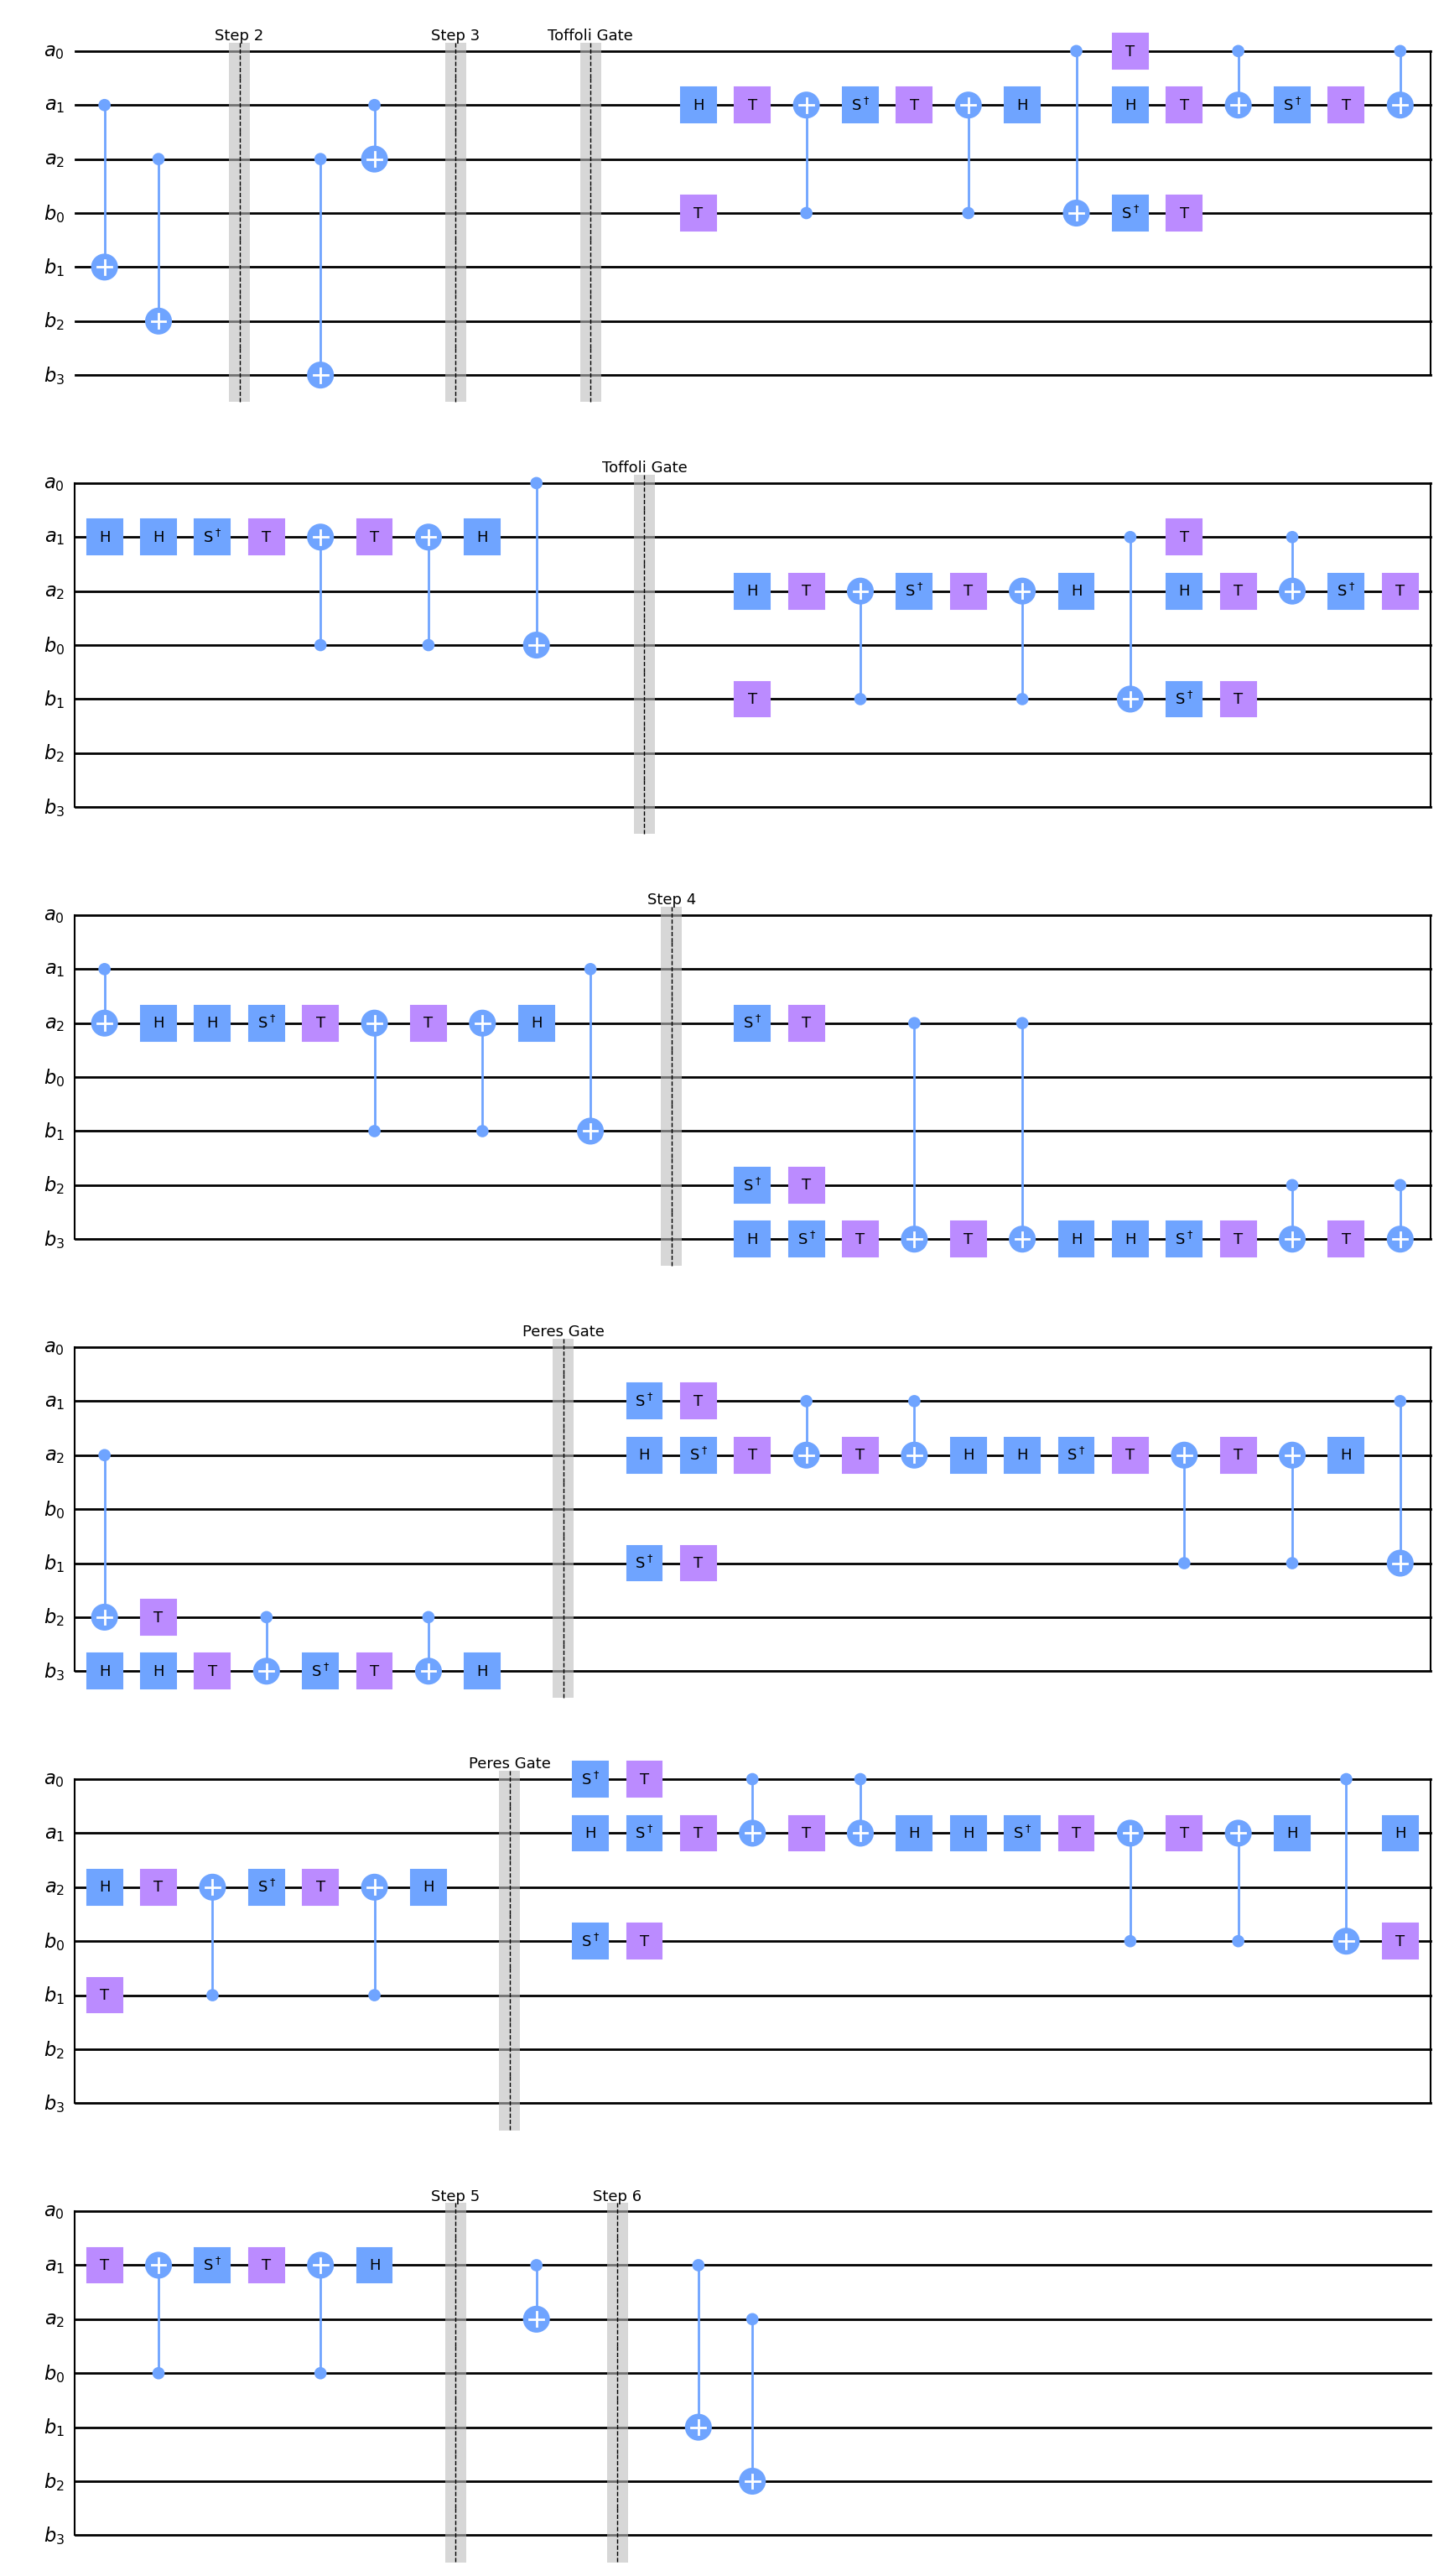

In [121]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register
b = QuantumRegister(n+1, 'b') # "B" register

qc = QuantumCircuit(a, b)

Addition_gate(qc, a, b, modular=False, useElementaryGates=True)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
for b_val in range(int(2**n)):
    for a_val in range(int(2**n)):
        integer_input = b_val * int(2**n) + a_val
        state_vec = np.zeros(int(2**(2*n+1)))
        state_vec[integer_input] = 1
        input_state = Statevector(state_vec)

        # Apply the circuit to the state
        output_state = input_state.evolve(qc)
        integer_output = np.argmax(output_state.data)
        output_a = integer_output % int(2**n)
        output_b = integer_output // int(2**n)

        # Print as numpy array
        #print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
        #print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)

        if output_a != a_val:
            print("output a is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output a is not correct")

        if output_b != (a_val + b_val) % int(2**(n+1)):
            print("output b is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output b is not correct")

print(dict(qc.count_ops()))
qc.draw('mpl')

# 1s Complement
Taking some binary representation of an integer, apply the X gate to every qubit:

$\ket{a}^n \rightarrow \ket{2^n - a - 1}^n$

$\ket{a}^n = \ket{a_{n}} \ket{a_{n-1}} \ldots \ket{a_0} \rightarrow \ket{a_{n} \oplus 1} \ket{a_{n-1} \oplus 1} \ldots \ket{a_0 \oplus 1}$

{'x': 3}


C:\Users\linco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


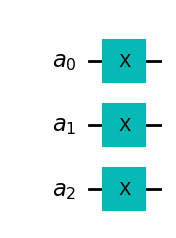

In [128]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register

qc = QuantumCircuit(a)

Ones_complement(qc, a)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
for a_val in range(int(2**n)):
    integer_input = a_val
    state_vec = np.zeros(int(2**n))
    state_vec[integer_input] = 1
    input_state = Statevector(state_vec)

    # Apply the circuit to the state
    output_state = input_state.evolve(qc)
    output_a = np.argmax(output_state.data)

    if output_a != int(2**n) - a_val - 1:
        print("output a is not correct")
        print("input: ", state_vec, "   a = ", a_val)
        print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a)
        #raise Exception("output a is not correct")


print(dict(qc.count_ops()))
qc.draw('mpl')

# 2s Complement
To create the 2s complement form of a positive integer $\ket{a}$, just add a leading $\ket{0}$: $\ket{a} = \ket{0}\ket{a}$

To find the negativeof an integer in 2s complement form, first apply the ones complement to all qubits, then add 1 to the result:

$\ket{a}^{n} \rightarrow \ket{-a}^{n}$

Ones complement step : $\ket{a}^{n} = \ket{a_{n}} \ket{a_{n-1}} \ldots \ket{a_0} \rightarrow \ket{a_{n} \oplus 1} \ket{a_{n-1} \oplus 1} \ldots \ket{a_0 \oplus 1}$


In the 2s complement form, the first (most significant) qubit represents a negative integer, whic allows the form to represent an integer in the range $(-2^n, 2^n-1)$ with n qubits

In [ ]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register

qc = QuantumCircuit(a)

Ones_complement(qc, a)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
for a_val in range(int(2**n)):
    integer_input = a_val
    state_vec = np.zeros(int(2**n))
    state_vec[integer_input] = 1
    input_state = Statevector(state_vec)

    # Apply the circuit to the state
    output_state = input_state.evolve(qc)
    output_a = np.argmax(output_state.data)

    if output_a != int(2**n) - a_val - 1:
        print("output a is not correct")
        print("input: ", state_vec, "   a = ", a_val)
        print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a)
        #raise Exception("output a is not correct")


print(dict(qc.count_ops()))
qc.draw('mpl')